#1) Install and load the YELP dataset (full) and binary labeling

In [1]:
# -*- coding: utf-8 -*-

!pip install -q datasets transformers wordcloud seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)
import random
from collections import Counter

plt.rcParams['font.family'] = 'DejaVu Sans'

# لود دیتاست کامل Yelp Review Full (650k train, 50k test) [web:6][web:8][web:21]
dataset = load_dataset("Yelp/yelp_review_full")

# تبدیل به دیتافریم
df_train = pd.DataFrame(dataset["train"])
df_test  = pd.DataFrame(dataset["test"])

print("Train shape:", df_train.shape)
print("Test shape :", df_test.shape)
print("\nFirst 5 rows of training data:")
print(df_train.head())

# تبدیل label چندکلاسه به sentiment باینری بر اساس ستاره
# label: 0..4 → stars: 1..5  (1,2 = منفی / 3,4,5 = مثبت) [web:19]
def stars_to_binary(label):
    stars = label + 1
    return 1 if stars >= 3 else 0

df_train["sentiment"] = df_train["label"].apply(stars_to_binary)
df_test["sentiment"]  = df_test["label"].apply(stars_to_binary)

print("\nTrain sentiment value counts:")
print(df_train["sentiment"].value_counts())
print("\nTest sentiment value counts:")
print(df_test["sentiment"].value_counts())


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

yelp_review_full/train-00000-of-00001.pa(…):   0%|          | 0.00/299M [00:00<?, ?B/s]

yelp_review_full/test-00000-of-00001.par(…):   0%|          | 0.00/23.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/650000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train shape: (650000, 2)
Test shape : (50000, 2)

First 5 rows of training data:
   label                                               text
0      4  dr. goldberg offers everything i look for in a...
1      1  Unfortunately, the frustration of being Dr. Go...
2      3  Been going to Dr. Goldberg for over 10 years. ...
3      3  Got a letter in the mail last week that said D...
4      0  I don't know what Dr. Goldberg was like before...

Train sentiment value counts:
sentiment
1    390000
0    260000
Name: count, dtype: int64

Test sentiment value counts:
sentiment
1    30000
0    20000
Name: count, dtype: int64


#Class distribution

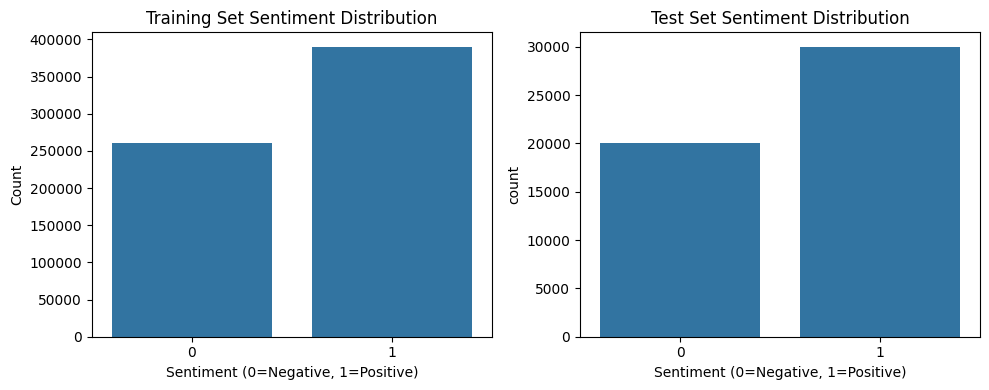

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(x="sentiment", data=df_train, ax=axes[0])
axes[0].set_title("Training Set Sentiment Distribution")
axes[0].set_xlabel("Sentiment (0=Negative, 1=Positive)")
axes[0].set_ylabel("Count")

sns.countplot(x="sentiment", data=df_test, ax=axes[1])
axes[1].set_title("Test Set Sentiment Distribution")
axes[1].set_xlabel("Sentiment (0=Negative, 1=Positive)")

plt.tight_layout()
plt.show()


#2) WordCloud and stopword extraction (like the Snappfood exercise)

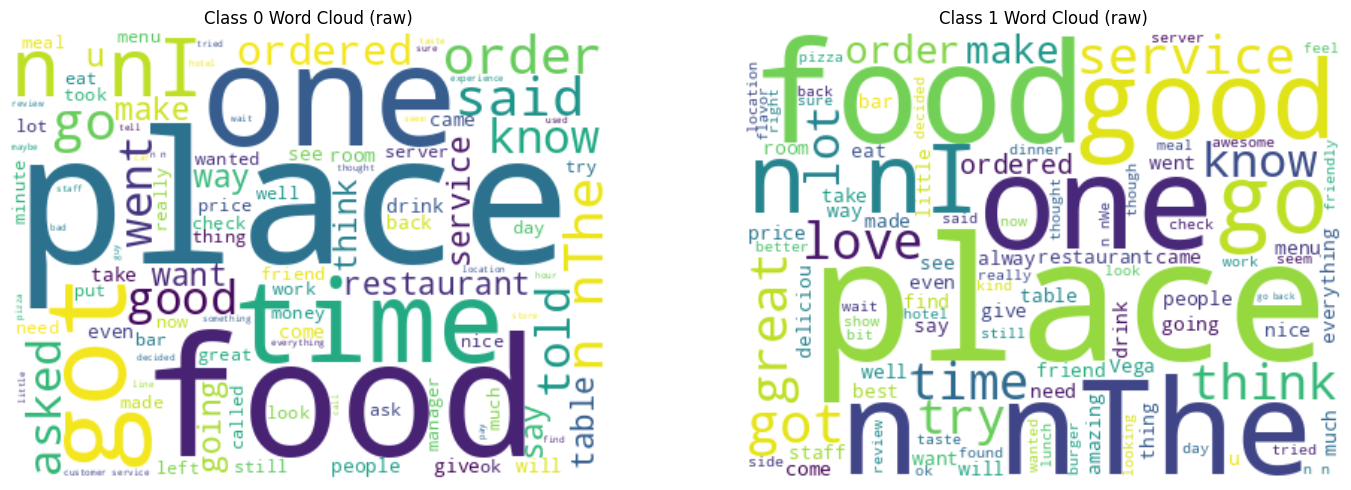

Most common words per class (raw):

Class 0: [('food', 123002), ('place', 117504), ('one', 105725), ('go', 83110), ('time', 82387), ('back', 79624), ('good', 78579), ('us', 78048), ('even', 77794), ('will', 75375)]

Class 1: [('place', 174760), ('good', 156022), ('food', 144536), ('really', 118251), ('great', 117824), ('one', 115962), ('go', 99030), ('time', 93570), ('-', 91871), ('will', 86437)]


In [3]:
from wordcloud import WordCloud, STOPWORDS
import os

# استاپ‌وردهای انگلیسی پایه
base_stopwords = set(STOPWORDS)

# ایجاد ابرکلمات برای هر کلاس (قبل از استخراج استاپ‌ورد مشترک)
classes = sorted(df_train["sentiment"].unique())

fig, axes = plt.subplots(1, len(classes), figsize=(15, 5))

for i, c in enumerate(classes):
    class_texts = " ".join(df_train[df_train["sentiment"] == c]["text"])
    wc = WordCloud(
        stopwords=base_stopwords,
        background_color="white",
        width=400,
        height=300,
        max_words=100
    ).generate(class_texts)

    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].set_title(f"Class {c} Word Cloud (raw)")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

print("Most common words per class (raw):")
for c in classes:
    class_texts = " ".join(df_train[df_train["sentiment"] == c]["text"])
    words = [w for w in class_texts.split() if w.lower() not in base_stopwords]
    common_words = Counter(words).most_common(10)
    print(f"\nClass {c}: {common_words}")


#Extracting common stopwords between classes

In [4]:
# استخراج 200 کلمه پرتکرار برای هر کلاس
class_word_counts = {}
top_n = 200

for c in classes:
    class_texts = " ".join(df_train[df_train["sentiment"] == c]["text"])
    words = [w.lower() for w in class_texts.split()]
    word_counts = Counter(words)
    top_words = set([w for w, cnt in word_counts.most_common(top_n)])
    class_word_counts[c] = top_words
    print(f"Class {c}: {len(top_words)} frequent words")

# کلمات مشترک = استاپ‌وردهای مخصوص دیتاست Yelp
common_words = set.intersection(*class_word_counts.values())
print(f"\nNumber of common frequent words across classes: {len(common_words)}")
print("Sample of common words:", list(common_words)[:50])

# استاپ‌ورد نهایی: استاپ‌وردهای wordcloud + کلمات مشترک
final_stopwords = base_stopwords.union(common_words)

def preprocess_text(text):
    words = text.split()
    filtered = [w for w in words if w.lower() not in final_stopwords]
    return " ".join(filtered)

# نمایش نمونه پیش‌پردازش
sample_text = df_train["text"].iloc[0]
print("\nSample preprocessing:")
print("Before:", sample_text)
print("After :", preprocess_text(sample_text))


Class 0: 200 frequent words
Class 1: 200 frequent words

Number of common frequent words across classes: 169
Sample of common words: ['much', 'next', 'that', 'as', 'good', 'other', 'after', 'into', 'what', 'took', 'have', 'out', "i'm", 'made', 'their', 'pretty', 'you', 'need', 'so', 'here', 'it.', 'being', 'order', 'people', 'off', 'like', 'many', 'long', 'because', 'great', 'go', 'been', "i've", 'and', 'am', 'going', 'any', 'another', 'ordered', 'do', 'she', 'from', "didn't", 'for', 'nice', 'one', 'take', 'before', 'how', 'be']

Sample preprocessing:
Before: dr. goldberg offers everything i look for in a general practitioner.  he's nice and easy to talk to without being patronizing; he's always on time in seeing his patients; he's affiliated with a top-notch hospital (nyu) which my parents have explained to me is very important in case something happens and you need surgery; and you can get referrals to see specialists without having to see him first.  really, what more do you need?  

#WordCloud after removing stopwords

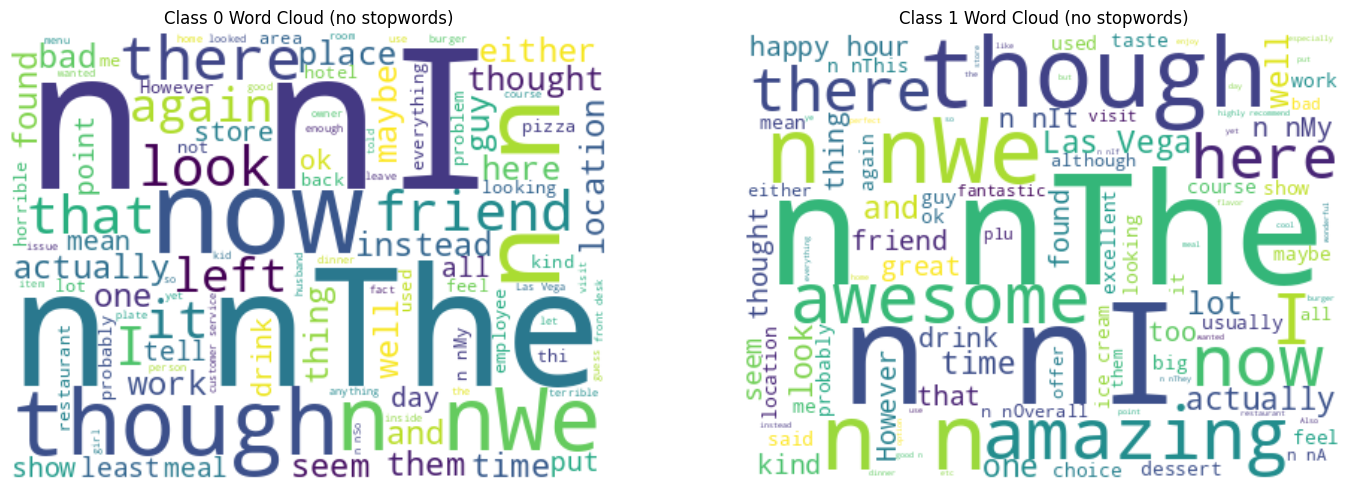


Most common words after removing stopwords:

Class 0: [('said', 61158), ('told', 57277), ('asked', 52887), ('minutes', 46114), ('bad', 33290), ('wanted', 31794), ('table', 28864), ('customer', 27283), ('called', 26605), ('experience', 26546)]

Class 1: [('best', 57772), ('love', 56424), ('definitely', 47900), ('bit', 45028), ('good.', 44581), ('menu', 39777), ('friendly', 35772), ('lot', 34234), ('every', 32093), ('\\n\\nThe', 31193)]


In [5]:
fig, axes = plt.subplots(1, len(classes), figsize=(15, 5))

for i, c in enumerate(classes):
    class_texts = " ".join(df_train[df_train["sentiment"] == c]["text"])
    processed = preprocess_text(class_texts)

    wc = WordCloud(
        stopwords=set(),
        background_color="white",
        width=400,
        height=300,
        max_words=100
    ).generate(processed)

    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].set_title(f"Class {c} Word Cloud (no stopwords)")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

print("\nMost common words after removing stopwords:")
for c in classes:
    class_texts = " ".join(df_train[df_train["sentiment"] == c]["text"])
    processed = preprocess_text(class_texts)
    words = processed.split()
    common_words_after = Counter(words).most_common(10)
    print(f"\nClass {c}: {common_words_after}")


#3) Random classifier on test data


نتایج ارزیابی کلاسیفایر تصادفی (Yelp)
Accuracy : 0.4995
Precision: 0.5197
Recall   : 0.4995
F1-score : 0.5045

Classification report:
              precision    recall  f1-score   support

    Negative     0.3997    0.5006    0.4444     20000
    Positive     0.5997    0.4987    0.5446     30000

    accuracy                         0.4995     50000
   macro avg     0.4997    0.4996    0.4945     50000
weighted avg     0.5197    0.4995    0.5045     50000



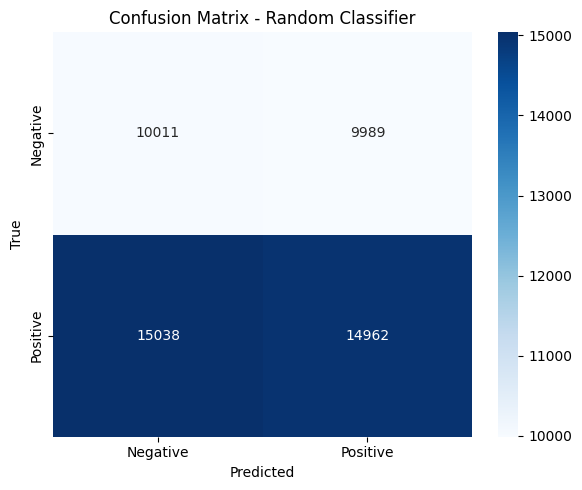

In [6]:
y_true = df_test["sentiment"].tolist()

# برچسب‌گذاری تصادفی
y_pred_random = [random.choice(classes) for _ in range(len(df_test))]

acc_random  = accuracy_score(y_true, y_pred_random)
prec_random = precision_score(y_true, y_pred_random, average="weighted")
rec_random  = recall_score(y_true, y_pred_random, average="weighted")
f1_random   = f1_score(y_true, y_pred_random, average="weighted")

print("\n" + "="*60)
print("نتایج ارزیابی کلاسیفایر تصادفی (Yelp)")
print("="*60)
print(f"Accuracy : {acc_random:.4f}")
print(f"Precision: {prec_random:.4f}")
print(f"Recall   : {rec_random:.4f}")
print(f"F1-score : {f1_random:.4f}")
print("\nClassification report:")
print(classification_report(y_true, y_pred_random, target_names=["Negative","Positive"], digits=4))

cm = confusion_matrix(y_true, y_pred_random)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative","Positive"],
            yticklabels=["Negative","Positive"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Random Classifier")
plt.tight_layout()
plt.show()


#4) Simple Heuristic Method



نتایج ارزیابی کلاسیفایر هیوریستیک (Yelp)
Accuracy : 0.7185
Precision: 0.7249
Recall   : 0.7185
F1-score : 0.6995

Classification report:
              precision    recall  f1-score   support

    Negative     0.7486    0.4460    0.5590     20000
    Positive     0.7091    0.9001    0.7933     30000

    accuracy                         0.7185     50000
   macro avg     0.7288    0.6731    0.6761     50000
weighted avg     0.7249    0.7185    0.6995     50000



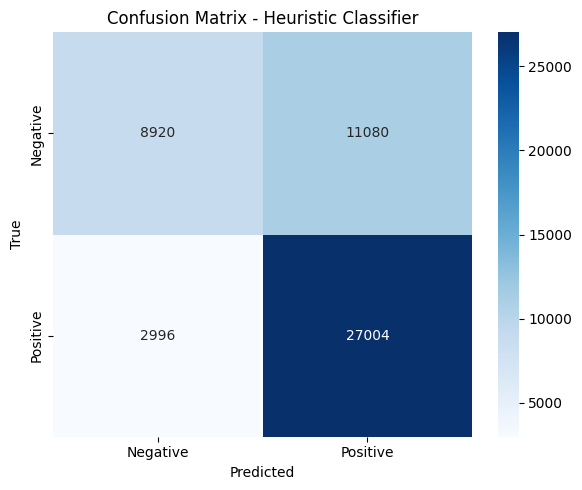

In [7]:
# لیست کلمات مثبت / منفی انگلیسی (ساده)
positive_words = {"good","great","excellent","amazing","love","loved","awesome","fantastic","perfect","delicious","friendly","nice","wonderful","best"}
negative_words = {"bad","terrible","awful","worst","horrible","disgusting","poor","hate","hated","rude","slow","dirty","cold","overpriced"}

def heuristic_predict(text):
    t = text.lower()
    pos = sum(w in t for w in positive_words)
    neg = sum(w in t for w in negative_words)
    if pos > neg:
        return 1
    elif neg > pos:
        return 0
    else:
        return random.choice(classes)

y_pred_heur = [heuristic_predict(t) for t in df_test["text"]]

acc_heur  = accuracy_score(y_true, y_pred_heur)
prec_heur = precision_score(y_true, y_pred_heur, average="weighted")
rec_heur  = recall_score(y_true, y_pred_heur, average="weighted")
f1_heur   = f1_score(y_true, y_pred_heur, average="weighted")

print("\n" + "="*60)
print("نتایج ارزیابی کلاسیفایر هیوریستیک (Yelp)")
print("="*60)
print(f"Accuracy : {acc_heur:.4f}")
print(f"Precision: {prec_heur:.4f}")
print(f"Recall   : {rec_heur:.4f}")
print(f"F1-score : {f1_heur:.4f}")
print("\nClassification report:")
print(classification_report(y_true, y_pred_heur, target_names=["Negative","Positive"], digits=4))

cm = confusion_matrix(y_true, y_pred_heur)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative","Positive"],
            yticklabels=["Negative","Positive"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Heuristic Classifier")
plt.tight_layout()
plt.show()


#5) Ready-made BERT model on Yelp (similar to ParsBERT for Snappfood)

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from tqdm.auto import tqdm

model_name = "textattack/bert-base-uncased-yelp-polarity"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()
print(f"Model loaded on {device}")

def bert_predict(texts, batch_size=32):
    preds = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[i:i+batch_size]
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=256,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
        batch_preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        preds.extend(batch_preds)
    return preds

test_texts = df_test["text"].tolist()
y_pred_bert = bert_predict(test_texts)

acc_bert  = accuracy_score(y_true, y_pred_bert)
prec_bert = precision_score(y_true, y_pred_bert, average="weighted")
rec_bert  = recall_score(y_true, y_pred_bert, average="weighted")
f1_bert   = f1_score(y_true, y_pred_bert, average="weighted")

print("\n" + "="*60)
print("نتایج ارزیابی مدل BERT روی Yelp (دوکلاسه)")
print("="*60)
print(f"Accuracy : {acc_bert:.4f}")
print(f"Precision: {prec_bert:.4f}")
print(f"Recall   : {rec_bert:.4f}")
print(f"F1-score : {f1_bert:.4f}")
print("\nClassification report:")
print(classification_report(y_true, y_pred_bert, target_names=["Negative","Positive"], digits=4))

cm = confusion_matrix(y_true, y_pred_bert)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative","Positive"],
            yticklabels=["Negative","Positive"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - BERT Yelp")
plt.tight_layout()
plt.show()


#5) Ready-made BERT model on Yelp (similar to ParsBERT for Snappfood)

#To avoid Colab time constraints, the BERT model was run on 2000 test instances.

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/520 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Model loaded on cpu


  0%|          | 0/125 [00:00<?, ?it/s]


BERT on Yelp (subset of 2000 samples)
Accuracy : 0.8915
Precision: 0.9139
Recall   : 0.8915
F1-score : 0.8928

Classification report:
              precision    recall  f1-score   support

    Negative     0.7847    0.9962    0.8779       783
    Positive     0.9970    0.8242    0.9024      1217

    accuracy                         0.8915      2000
   macro avg     0.8909    0.9102    0.8901      2000
weighted avg     0.9139    0.8915    0.8928      2000



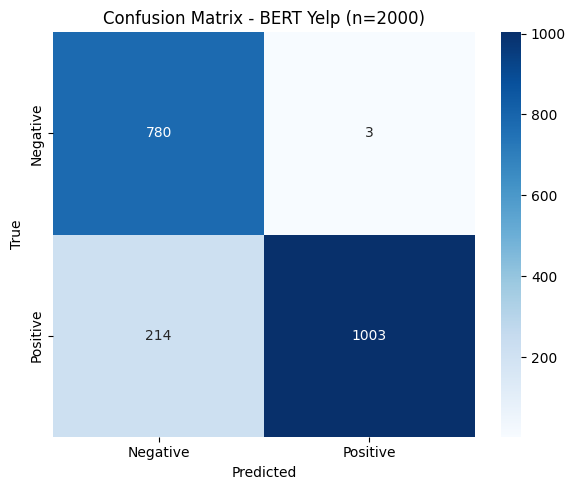

In [8]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from tqdm.auto import tqdm

model_name = "textattack/bert-base-uncased-yelp-polarity"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()
print(f"Model loaded on {device}")

def bert_predict(texts, batch_size=16):
    preds = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[i:i+batch_size]
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=256,
            return_tensors="pt"
        ).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        batch_preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        preds.extend(batch_preds)
    return preds

subset_size = 2000
test_texts_subset = df_test["text"].tolist()[:subset_size]
y_true_subset = y_true[:subset_size]

y_pred_bert = bert_predict(test_texts_subset, batch_size=16)

acc_bert  = accuracy_score(y_true_subset, y_pred_bert)
prec_bert = precision_score(y_true_subset, y_pred_bert, average="weighted")
rec_bert  = recall_score(y_true_subset, y_pred_bert, average="weighted")
f1_bert   = f1_score(y_true_subset, y_pred_bert, average="weighted")

print("\n" + "="*60)
print(f"BERT on Yelp (subset of {subset_size} samples)")
print("="*60)
print(f"Accuracy : {acc_bert:.4f}")
print(f"Precision: {prec_bert:.4f}")
print(f"Recall   : {rec_bert:.4f}")
print(f"F1-score : {f1_bert:.4f}")

print("\nClassification report:")
print(classification_report(
    y_true_subset, y_pred_bert,
    target_names=["Negative","Positive"],
    digits=4
))

cm = confusion_matrix(y_true_subset, y_pred_bert)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative","Positive"],
            yticklabels=["Negative","Positive"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix - BERT Yelp (n={subset_size})")
plt.tight_layout()
plt.show()


#6) Final comparison table of the three methods

In [9]:
results = pd.DataFrame([
    ["Random",    acc_random,  prec_random,  rec_random,  f1_random],
    ["Heuristic", acc_heur,    prec_heur,    rec_heur,    f1_heur],
    ["BERT",      acc_bert,    prec_bert,    rec_bert,    f1_bert],
], columns=["Model", "Accuracy", "Precision", "Recall", "F1"])

print("\nOverall comparison:")
print(results)




Overall comparison:
       Model  Accuracy  Precision   Recall        F1
0     Random   0.49946   0.519656  0.49946  0.504514
1  Heuristic   0.71848   0.724868  0.71848  0.699540
2       BERT   0.89150   0.913899  0.89150  0.892792
